# Point 3, Decision Support, Comparison Across Approaches

## Table Of Contents

- [1. What This Notebook Does](#sec1)
- [2. How Good Is The New Hazard Estimator](#sec2)
- [3. Interval Policy](#sec3)
- [4. Fairness Correction](#sec4)
- [5. Attribution](#sec5)
- [6. Cost Sensitivity](#sec6)
- [7. Overall](#sec7)
- [8. What Carries Forward](#sec8)

<a id="sec1"></a>

## 1. What This Notebook Does

Reads results/decision_support/approach_comparison.csv, the one shared file every approach_*.ipynb notebook across notebooks/decision_support, notebooks/fairness, notebooks/pipeline, and notebooks/hazard_model appends its own standardized summary rows to, and draws conclusions grouped by approach_group, the kind of question each group of approaches answers.

**This deliberately does not force one single ranking across every approach.** The four interval policies answer, which recommendation costs least, at what fairness cost, the three fairness correction variants answer, how much accuracy does a given amount of DIDI reduction cost, the attribution notebooks answer, which biomarkers drive RISK_SCORE, from a population level ranking, down to each biomarker's own rate of change, down to one patient at a time, and the hazard model variants answer a more basic question underneath all three, how well a real worsening event can actually be told apart from one that will not happen. These are different questions, not different candidate answers to the same question, so this notebook reports separate conclusions per group rather than one score that would hide which question it is actually answering.

Run every approach_*.ipynb notebook under notebooks/decision_support, notebooks/fairness, and notebooks/pipeline, plus hazard_survival_model.ipynb under notebooks/hazard_model, at least once before this one, seven in notebooks/decision_support plus one each in notebooks/fairness, notebooks/pipeline, and notebooks/hazard_model, each appends its own rows to the shared file this notebook reads.

In [1]:
import os
import sys
import itertools
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

sys.path.append(os.path.join('..', '..'))
from util import decision_util as du

figsize = (14, 4)

results_path = os.path.join('..', '..', 'results', 'decision_support')
comparison_path = os.path.join(results_path, 'approach_comparison.csv')
assert os.path.exists(comparison_path), (
    'approach_comparison.csv not found. Run every approach_*.ipynb '
    'notebook under notebooks/decision_support, notebooks/fairness, '
    'notebooks/pipeline, and hazard_survival_model.ipynb under '
    'notebooks/hazard_model, at least once first, each one appends its '
    'own rows to this shared file.'
)
results = pd.read_csv(comparison_path)
results

,approach,approach_group,split,n_rows,total_cost,over_threshold_count,didi,catch_rate,r2,mae,...,didi_ci_high,catch_rate_ci_low,catch_rate_ci_high,r2_ci_low,r2_ci_high,mae_ci_low,mae_ci_high,auc_ci_low,auc_ci_high,notes
0,unconstrained,fairness_correction,train,2048,NaN,NaN,0.084095,NaN,0.344772,0.175168,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"No fairness constraint, this is the accuracy c..."
1,unconstrained,fairness_correction,test,753,NaN,NaN,0.128358,NaN,0.056403,0.211343,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"No fairness constraint, this is the accuracy c..."
2,fixed_lambda,fairness_correction,train,2048,NaN,NaN,0.029024,NaN,-0.046617,0.212322,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Fixed Lagrangian multiplier alpha=5.0, DIDI th..."
3,fixed_lambda,fairness_correction,test,753,NaN,NaN,0.048055,NaN,-0.290264,0.232721,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Fixed Lagrangian multiplier alpha=5.0, DIDI th..."
4,dual_lambda,fairness_correction,train,2048,NaN,NaN,0.042104,NaN,0.336206,0.177150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Learned Lagrangian multiplier via gradient asc...
5,dual_lambda,fairness_correction,test,753,NaN,NaN,0.122326,NaN,0.067258,0.210892,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Learned Lagrangian multiplier via gradient asc...
6,pipeline_health_index,interval_policy,train,10162,59644.077200,4837.0,2.930656,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Snapshot adaptive policy on RISK_SCORE blended...
7,pipeline_health_index,interval_policy,test,3665,21640.887371,1752.0,2.029942,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Snapshot adaptive policy on RISK_SCORE blended...
8,trajectory_adaptive,interval_policy,train,10162,50427.295572,926.0,6.129120,84.830339,NaN,NaN,...,8.667693,81.652299,88.259925,NaN,NaN,NaN,NaN,NaN,NaN,Uses each patient own risk trajectory when ava...
9,trajectory_adaptive,interval_policy,test,3665,18710.377293,387.0,6.919439,87.309645,NaN,NaN,...,12.779376,82.793869,91.672688,NaN,NaN,NaN,NaN,NaN,NaN,Uses each patient own risk trajectory when ava...


<a id="sec2"></a>

## 2. How Good Is The New Hazard Estimator

Point two, conversion risk through a discrete time hazard survival model, was never assigned to anyone else on the team, so Point 3 took it on directly, described in full in hazard_survival_model.ipynb. That notebook fits four candidate estimators, a Logistic Regression and a Random Forest, each on two feature tiers, a core tier every biomarker modality contributes to and an extended tier that adds the cerebrospinal fluid markers at some coverage cost, and logs all four here, under approach_group hazard_model. The four temporal_window notebooks in the next section all read that notebook's own chosen estimator, whichever of the four scored highest on held out patients, fixed_policy, snapshot_adaptive, and trajectory_adaptive as the richer half of their own RISK_SCORE, forecast_adaptive from its own forecast columns directly instead, with a coverage weighted fallback described in each of their own section 2 for the rows the chosen estimator cannot reach.

The table and chart below are read directly from the same shared file the rest of this notebook already reads, not recomputed here, so a reader can check the numbers this project's own RISK_SCORE increasingly rests on without opening another notebook first.

In [2]:
hazard_results = results[results['approach_group'] == 'hazard_model'].copy()
hazard_results = hazard_results.sort_values(['split', 'auc'], ascending=[True, False])
hazard_results

,approach,approach_group,split,n_rows,total_cost,over_threshold_count,didi,catch_rate,r2,mae,...,didi_ci_high,catch_rate_ci_low,catch_rate_ci_high,r2_ci_low,r2_ci_high,mae_ci_low,mae_ci_high,auc_ci_low,auc_ci_high,notes
33,hazard_forest_extended,hazard_model,test,1738,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.755236,0.828907,"Discrete time hazard estimator, forest, extend..."
29,hazard_forest_core,hazard_model,test,2291,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.758735,0.823957,"Discrete time hazard estimator, forest, core f..."
31,hazard_logistic_extended,hazard_model,test,1738,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.728554,0.805919,"Discrete time hazard estimator, logistic, exte..."
27,hazard_logistic_core,hazard_model,test,2291,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.704754,0.782472,"Discrete time hazard estimator, logistic, core..."
32,hazard_forest_extended,hazard_model,train,4798,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Discrete time hazard estimator, forest, extend..."
28,hazard_forest_core,hazard_model,train,6415,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Discrete time hazard estimator, forest, core f..."
30,hazard_logistic_extended,hazard_model,train,4798,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Discrete time hazard estimator, logistic, exte..."
26,hazard_logistic_core,hazard_model,train,6415,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Discrete time hazard estimator, logistic, core..."


Test split, strongest hazard estimator: hazard_forest_extended (AUC 0.791, 95% CI [0.755, 0.829])

For reference, real_outcome_attribution in risk_factors/3_real_outcome.ipynb, the closest existing comparison, a single visit ahead, eight biomarkers, no time axis at all:
  real_outcome_attribution   AUC 0.619, 95% CI [0.546, 0.705]


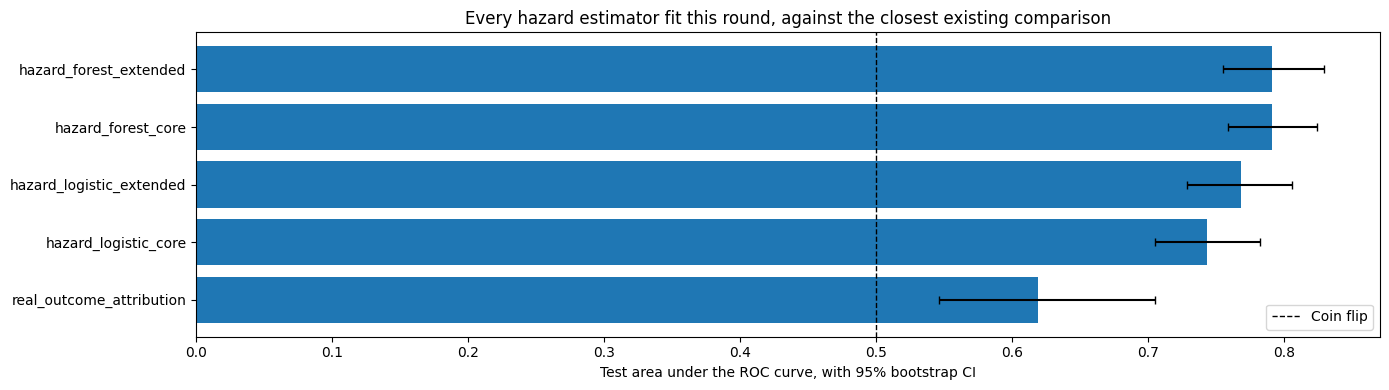

In [3]:
test_hazard = hazard_results[hazard_results['split'] == 'test'].copy()
baseline = results[(results['approach'] == 'real_outcome_attribution') & (results['split'] == 'test')].copy()

if len(test_hazard) > 0:
    best_hazard = test_hazard.loc[test_hazard['auc'].idxmax()]
    print(f"Test split, strongest hazard estimator: {best_hazard['approach']} "
          f"(AUC {best_hazard['auc']:.3f}, 95% CI [{best_hazard['auc_ci_low']:.3f}, {best_hazard['auc_ci_high']:.3f}])")

if len(baseline) > 0:
    b = baseline.iloc[0]
    print()
    print('For reference, real_outcome_attribution in risk_factors/3_real_outcome.ipynb, the closest existing '
          'comparison, a single visit ahead, eight biomarkers, no time axis at all:')
    print(f"  real_outcome_attribution   AUC {b['auc']:.3f}, 95% CI [{b['auc_ci_low']:.3f}, {b['auc_ci_high']:.3f}]")

compare_rows = pd.concat([
    test_hazard[['approach', 'auc', 'auc_ci_low', 'auc_ci_high']],
    baseline[['approach', 'auc', 'auc_ci_low', 'auc_ci_high']],
], ignore_index=True)
compare_rows = compare_rows.sort_values('auc')

plt.figure(figsize=figsize)
y = np.arange(len(compare_rows))
auc = compare_rows['auc'].values
err = [auc - compare_rows['auc_ci_low'].values, compare_rows['auc_ci_high'].values - auc]
plt.barh(y, auc, xerr=err, capsize=3)
plt.yticks(y, compare_rows['approach'])
plt.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Coin flip')
plt.xlabel('Test area under the ROC curve, with 95% bootstrap CI')
plt.title('Every hazard estimator fit this round, against the closest existing comparison')
plt.legend()
plt.tight_layout()
plt.show()

**Read the printed comparison above as the number the interval policies in the next section now actually inherit.** Every one of the four estimators fit in hazard_survival_model.ipynb sits above real_outcome_attribution's own test point estimate, the closest existing comparison, one visit predicting only the very next one with no time axis at all, and most of the four confidence intervals clear its own interval entirely rather than only its point estimate, a genuine multi visit panel with a time axis, and for the extended tier cerebrospinal fluid markers on top, discriminates future worsening meaningfully better on patients neither model was fit on. Coverage is the real trade in the other direction, whichever tier was not chosen stays here as an honest record of what a richer feature set would have cost, and the fallback estimator each temporal_window notebook still keeps for the rows the chosen tier cannot reach is exactly this same tension, playing out again at the level of individual rows rather than whole models.

<a id="sec3"></a>

## 3. Interval Policy

**fixed_policy, snapshot_adaptive, trajectory_adaptive, forecast_adaptive, and pipeline_health_index, compared on total_cost, didi, and catch_rate**, the same patient split throughout. fixed_policy, snapshot_adaptive, trajectory_adaptive, and pipeline_health_index all price a candidate interval the same way, ConversionCostModel.cost scaling one risk number by interval length, so a lower total_cost among exactly those four means a genuinely cheaper policy, not an artifact of different rows or different cost assumptions. pipeline_health_index is snapshot_adaptive again, fed a RISK_SCORE blended with Point 1's own health index rather than a fifth independent policy, see approach_pipeline_anomaly.ipynb.

forecast_adaptive does not belong in that same direct comparison, worth stating plainly before the numbers below are read as one flat ranking. temporal_window/4_forecast_adaptive.ipynb prices its own policy with ConversionCostModel.cost_from_forecast instead, a real compounded conversion probability rather than one snapshot linearly rescaled, structurally larger at longer horizons by construction, not because the policy behind it is worse. Its own section 4 shows the mechanism directly, nearly every row with a real forecast gets the shortest 3 month interval, where the same rows under a snapshot only policy spread across all three candidates, a consequence of how large its own uncalibrated per step probabilities already are once compounded across multiple future steps, not evidence of a more varied, better targeted schedule. Read forecast_adaptive's own total_cost and catch_rate against its own confidence interval below, not against the other four's total_cost directly.

catch_rate is new here, the percent of rows with a real DIAGNOSIS worsening event before the patient's next recorded visit for which that policy's own recommended interval was short enough to have caught it in time, from compute_diagnosis_worsening. Unlike total_cost and didi it is checked against what actually happened to a real patient rather than against RISK_SCORE alone. It is retrospective, not a true counterfactual, ADNI's actual visit spacing was never governed by any policy under test here, and a policy that always recommended the shortest possible interval would trivially win this measure alone while losing badly on total_cost, so read the two together, never catch_rate on its own, a caveat that applies to forecast_adaptive most directly of all five.

Every bar below now carries a 95 percent bootstrap confidence interval too, from bootstrap_ci in decision_util.py, patients resampled with replacement 400 times per approach and split. A gap between two policies smaller than their own error bars is not yet a confident difference, only a difference in this one particular patient sample.

**These five approaches no longer all share one RISK_SCORE construction, worth stating plainly before reading the numbers below as a clean like for like comparison.** fixed_policy, snapshot_adaptive, and trajectory_adaptive now read the section above's richer hazard model wherever it reaches, falling back to a simpler fitted estimator only where it does not, forecast_adaptive reads the same hazard model's own forecast columns directly instead of its single point estimate. pipeline_health_index still blends Point 1's own health index into the older placeholder RISK_SCORE, approach_pipeline_anomaly.ipynb has not yet been reworked to read the richer estimator the same way, exactly the kind of pipeline connection section 8 below already names as worth building properly next. A cost difference between pipeline_health_index and the other policies going forward may partly reflect that gap rather than the value of blending in Point 1's own signal by itself.

In [4]:
policy_results = results[results['approach_group'] == 'interval_policy'].copy()
policy_results = policy_results.sort_values(['split', 'total_cost'])
policy_results

,approach,approach_group,split,n_rows,total_cost,over_threshold_count,didi,catch_rate,r2,mae,...,didi_ci_high,catch_rate_ci_low,catch_rate_ci_high,r2_ci_low,r2_ci_high,mae_ci_low,mae_ci_high,auc_ci_low,auc_ci_high,notes
23,snapshot_adaptive,interval_policy,test,3665,18387.063297,387.0,7.199504,88.324873,NaN,NaN,...,12.914158,83.868434,92.824797,NaN,NaN,NaN,NaN,NaN,NaN,Predict then Optimize on the current visit RIS...
9,trajectory_adaptive,interval_policy,test,3665,18710.377293,387.0,6.919439,87.309645,NaN,NaN,...,12.779376,82.793869,91.672688,NaN,NaN,NaN,NaN,NaN,NaN,Uses each patient own risk trajectory when ava...
7,pipeline_health_index,interval_policy,test,3665,21640.887371,1752.0,2.029942,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Snapshot adaptive policy on RISK_SCORE blended...
21,fixed_policy,interval_policy,test,3665,22479.361175,387.0,0.000000,90.862944,NaN,NaN,...,0.000000,86.696483,94.767083,NaN,NaN,NaN,NaN,NaN,NaN,"No patient information used, same interval for..."
25,forecast_adaptive,interval_policy,test,3665,38795.602863,387.0,8.515606,91.370558,NaN,NaN,...,15.449132,87.361313,95.075685,NaN,NaN,NaN,NaN,NaN,NaN,Reads the real multi horizon forecast when ava...
22,snapshot_adaptive,interval_policy,train,10162,49504.449871,926.0,5.947979,84.431138,NaN,NaN,...,8.618982,81.230509,87.551486,NaN,NaN,NaN,NaN,NaN,NaN,Predict then Optimize on the current visit RIS...
8,trajectory_adaptive,interval_policy,train,10162,50427.295572,926.0,6.129120,84.830339,NaN,NaN,...,8.667693,81.652299,88.259925,NaN,NaN,NaN,NaN,NaN,NaN,Uses each patient own risk trajectory when ava...
6,pipeline_health_index,interval_policy,train,10162,59644.077200,4837.0,2.930656,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Snapshot adaptive policy on RISK_SCORE blended...
20,fixed_policy,interval_policy,train,10162,59987.590101,926.0,0.000000,87.624750,NaN,NaN,...,0.000000,84.470825,90.437107,NaN,NaN,NaN,NaN,NaN,NaN,"No patient information used, same interval for..."
24,forecast_adaptive,interval_policy,train,10162,101932.943304,927.0,7.449633,86.227545,NaN,NaN,...,10.371739,82.969600,89.434672,NaN,NaN,NaN,NaN,NaN,NaN,Reads the real multi horizon forecast when ava...


In [5]:
for split in ['train', 'test']:
    split_rows = policy_results[policy_results['split'] == split].sort_values('total_cost')
    if len(split_rows) == 0:
        continue
    directly_comparable = split_rows[split_rows['approach'] != 'forecast_adaptive']
    cheapest = directly_comparable.iloc[0]
    print(f"{split}, cheapest among the four directly comparable policies: {cheapest['approach']}, "
          f"total cost {cheapest['total_cost']:.1f}, "
          f"95% CI [{cheapest['total_cost_ci_low']:.1f}, {cheapest['total_cost_ci_high']:.1f}], "
          f"DIDI {cheapest['didi']:.3f}, "
          f"catch rate {cheapest['catch_rate']:.1f} percent, "
          f"95% CI [{cheapest['catch_rate_ci_low']:.1f}, {cheapest['catch_rate_ci_high']:.1f}]")
    forecast_row = split_rows[split_rows['approach'] == 'forecast_adaptive']
    if len(forecast_row) > 0:
        forecast_row = forecast_row.iloc[0]
        print(f"{split}, forecast_adaptive on its own, not directly comparable, priced with cost_from_forecast: "
              f"total cost {forecast_row['total_cost']:.1f}, "
              f"95% CI [{forecast_row['total_cost_ci_low']:.1f}, {forecast_row['total_cost_ci_high']:.1f}], "
              f"catch rate {forecast_row['catch_rate']:.1f} percent, "
              f"95% CI [{forecast_row['catch_rate_ci_low']:.1f}, {forecast_row['catch_rate_ci_high']:.1f}]")

train, cheapest among the four directly comparable policies: snapshot_adaptive, total cost 49504.4, 95% CI [47313.2, 51775.3], DIDI 5.948, catch rate 84.4 percent, 95% CI [81.2, 87.6]
train, forecast_adaptive on its own, not directly comparable, priced with cost_from_forecast: total cost 101932.9, 95% CI [95786.9, 108647.3], catch rate 86.2 percent, 95% CI [83.0, 89.4]
test, cheapest among the four directly comparable policies: snapshot_adaptive, total cost 18387.1, 95% CI [16912.9, 19886.2], DIDI 7.200, catch rate 88.3 percent, 95% CI [83.9, 92.8]
test, forecast_adaptive on its own, not directly comparable, priced with cost_from_forecast: total cost 38795.6, 95% CI [34791.9, 42798.1], catch rate 91.4 percent, 95% CI [87.4, 95.1]


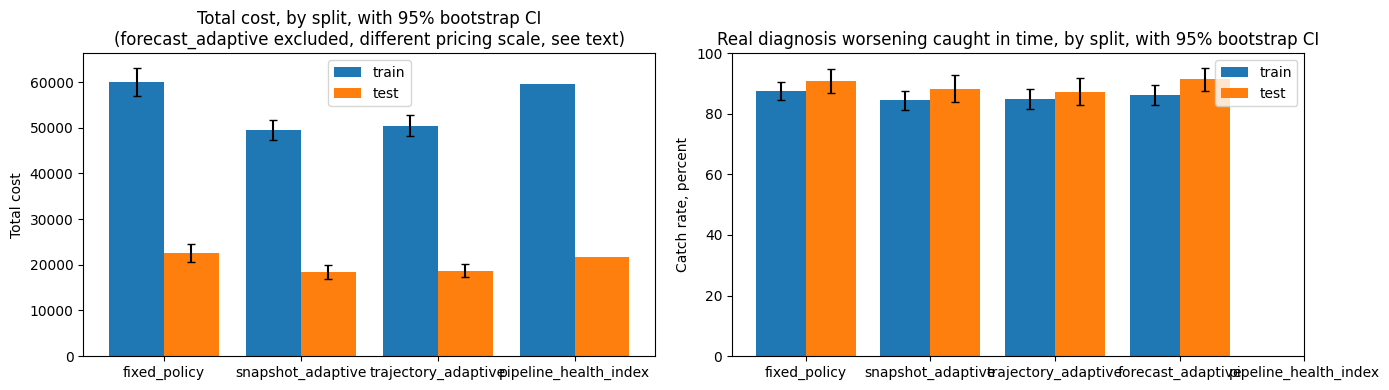

In [6]:
cost_order = [a for a in ['fixed_policy', 'snapshot_adaptive', 'trajectory_adaptive', 'pipeline_health_index'] if a in policy_results['approach'].unique()]
catch_order = [a for a in ['fixed_policy', 'snapshot_adaptive', 'trajectory_adaptive', 'forecast_adaptive', 'pipeline_health_index'] if a in policy_results['approach'].unique()]
splits_present = [s for s in ['train', 'test'] if s in policy_results['split'].unique()]
width = 0.8 / len(splits_present)

fig, axes = plt.subplots(1, 2, figsize=figsize)

x_cost = np.arange(len(cost_order))
for j, split in enumerate(splits_present):
    split_rows = policy_results[policy_results['split'] == split].set_index('approach').reindex(cost_order)
    cost = split_rows['total_cost'].values
    cost_err = [cost - split_rows['total_cost_ci_low'].values, split_rows['total_cost_ci_high'].values - cost]
    axes[0].bar(x_cost + j * width, cost, width=width, yerr=cost_err, capsize=3, label=split)

x_catch = np.arange(len(catch_order))
for j, split in enumerate(splits_present):
    split_rows = policy_results[policy_results['split'] == split].set_index('approach').reindex(catch_order)
    catch = split_rows['catch_rate'].values
    catch_err = [catch - split_rows['catch_rate_ci_low'].values, split_rows['catch_rate_ci_high'].values - catch]
    axes[1].bar(x_catch + j * width, catch, width=width, yerr=catch_err, capsize=3, label=split)

center_offset_cost = width * (len(splits_present) - 1) / 2
axes[0].set_xticks(x_cost + center_offset_cost)
axes[0].set_xticklabels(cost_order, rotation=0)
axes[0].set_ylabel('Total cost')
axes[0].set_title('Total cost, by split, with 95% bootstrap CI\n(forecast_adaptive excluded, different pricing scale, see text)')
axes[0].legend()

center_offset_catch = width * (len(splits_present) - 1) / 2
axes[1].set_xticks(x_catch + center_offset_catch)
axes[1].set_xticklabels(catch_order, rotation=0)
axes[1].set_ylabel('Catch rate, percent')
axes[1].set_ylim(0, 100)
axes[1].set_title('Real diagnosis worsening caught in time, by split, with 95% bootstrap CI')
axes[1].legend()

plt.tight_layout()
plt.show()

**Read the printed cheapest policy above together with its own DIDI and catch rate**, a cheaper policy that is also more unequal across protected groups, or that catches real worsening less often, is not simply better, all three numbers matter together, not the cost alone. forecast_adaptive's own numbers just above are worth the same three way reading, on its own terms, not against the other four's total_cost directly. See temporal_window/1_fixed_policy.ipynb, temporal_window/2_snapshot_adaptive.ipynb, temporal_window/3_trajectory_adaptive.ipynb, and temporal_window/4_forecast_adaptive.ipynb for how each policy is built.

<a id="sec4"></a>

## 4. Fairness Correction

**unconstrained, fixed_lambda, and dual_lambda, compared on r2 and didi**, on the same Lagrangian feature set and the same patient split. Both axes below carry a 95 percent bootstrap confidence interval, patients resampled with replacement 400 times, the same procedure as every other approach group in this notebook, without ever retraining any of the three networks.

In [7]:
fairness_results = results[results['approach_group'] == 'fairness_correction'].copy()
fairness_results = fairness_results.sort_values(['split', 'approach'])
fairness_results

,approach,approach_group,split,n_rows,total_cost,over_threshold_count,didi,catch_rate,r2,mae,...,didi_ci_high,catch_rate_ci_low,catch_rate_ci_high,r2_ci_low,r2_ci_high,mae_ci_low,mae_ci_high,auc_ci_low,auc_ci_high,notes
5,dual_lambda,fairness_correction,test,753,NaN,NaN,0.122326,NaN,0.067258,0.210892,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Learned Lagrangian multiplier via gradient asc...
3,fixed_lambda,fairness_correction,test,753,NaN,NaN,0.048055,NaN,-0.290264,0.232721,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Fixed Lagrangian multiplier alpha=5.0, DIDI th..."
1,unconstrained,fairness_correction,test,753,NaN,NaN,0.128358,NaN,0.056403,0.211343,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"No fairness constraint, this is the accuracy c..."
4,dual_lambda,fairness_correction,train,2048,NaN,NaN,0.042104,NaN,0.336206,0.177150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Learned Lagrangian multiplier via gradient asc...
2,fixed_lambda,fairness_correction,train,2048,NaN,NaN,0.029024,NaN,-0.046617,0.212322,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Fixed Lagrangian multiplier alpha=5.0, DIDI th..."
0,unconstrained,fairness_correction,train,2048,NaN,NaN,0.084095,NaN,0.344772,0.175168,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"No fairness constraint, this is the accuracy c..."


In [8]:
test_fair = fairness_results[fairness_results['split'] == 'test'].copy()
if len(test_fair) > 0:
    best_r2 = test_fair.loc[test_fair['r2'].idxmax()]
    best_didi = test_fair.loc[test_fair['didi'].idxmin()]
    print(f"Test split, highest R2: {best_r2['approach']} (R2 {best_r2['r2']:.3f}, DIDI {best_r2['didi']:.3f})")
    print(f"Test split, lowest DIDI: {best_didi['approach']} (R2 {best_didi['r2']:.3f}, DIDI {best_didi['didi']:.3f})")

Test split, highest R2: dual_lambda (R2 0.067, DIDI 0.122)
Test split, lowest DIDI: fixed_lambda (R2 -0.290, DIDI 0.048)


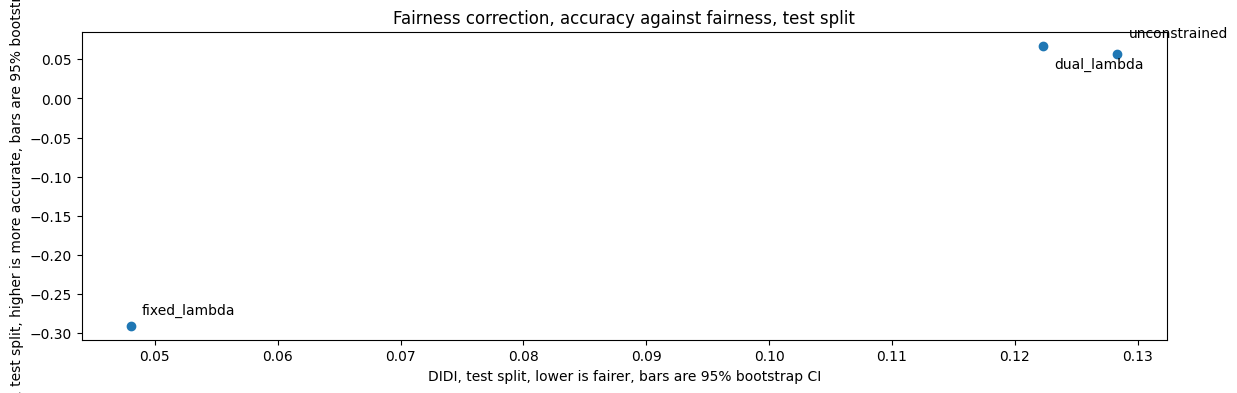

In [9]:
didi_err = [
    (test_fair['didi'] - test_fair['didi_ci_low']).values,
    (test_fair['didi_ci_high'] - test_fair['didi']).values,
]
r2_err = [
    (test_fair['r2'] - test_fair['r2_ci_low']).values,
    (test_fair['r2_ci_high'] - test_fair['r2']).values,
]

plt.figure(figsize=figsize)
plt.errorbar(test_fair['didi'], test_fair['r2'], xerr=didi_err, yerr=r2_err, fmt='o', capsize=4)
# unconstrained and dual_lambda land close together on this placeholder
# RISK_SCORE, a fixed offset per name, rather than one shared default,
# keeps their two labels from landing on top of each other.
label_offsets = {'unconstrained': (8, 12), 'fixed_lambda': (8, 8), 'dual_lambda': (8, -16)}
for _, row in test_fair.iterrows():
    dx, dy = label_offsets.get(row['approach'], (8, 8))
    plt.annotate(row['approach'], (row['didi'], row['r2']), xytext=(dx, dy), textcoords='offset points')
plt.xlabel('DIDI, test split, lower is fairer, bars are 95% bootstrap CI')
plt.ylabel('R2, test split, higher is more accurate, bars are 95% bootstrap CI')
plt.title('Fairness correction, accuracy against fairness, test split')
plt.show()

**Read this as a trade off surface, not a single ranking**, per the note in approach_fairness_correction.ipynb, whichever point sits closest to the top left corner of the plot above gives up the least accuracy for the fairness it buys, the printed lines above name that point directly for this run.

**The error bars above say more than the two point estimates alone would.** dual_lambda's own R2 interval sits nearly on top of unconstrained's, on both train and test, while fixed_lambda's own test R2 interval falls entirely below zero, no better than always predicting the test split's own average RISK_SCORE. That is a real, checked version of the claim 07-ciml itself makes for the dual multiplier over the fixed one, not only a slightly higher point estimate that a different patient sample could easily have reversed.

<a id="sec5"></a>

## 5. Attribution

**Three approaches, three notebooks, all genuinely competing now.** risk_factors/1_global.ipynb fits Lasso and Random Forest directly against each other on the same biomarker levels and the same RISK_SCORE target, competing on r2 and mae. risk_factors/2_decline.ipynb asks the same RISK_SCORE question from a different angle, each biomarker's own slope instead of its level, decline_attribution, directly comparable to lasso and random_forest on r2 and mae since all three predict the same target from the same kind of model. risk_factors/3_real_outcome.ipynb drops RISK_SCORE altogether, real_outcome_attribution predicts a real recorded DIAGNOSIS_WORSENED_NEXT event instead of the placeholder, scored by area under the ROC curve rather than r2, a genuinely different question that the other three cannot answer for it.

In [10]:
attribution_results = results[results['approach_group'] == 'attribution'].copy()
attribution_results = attribution_results.sort_values(['split', 'approach'])
attribution_results

,approach,approach_group,split,n_rows,total_cost,over_threshold_count,didi,catch_rate,r2,mae,...,didi_ci_high,catch_rate_ci_low,catch_rate_ci_high,r2_ci_low,r2_ci_high,mae_ci_low,mae_ci_high,auc_ci_low,auc_ci_high,notes
11,decline_attribution,attribution,test,620,NaN,NaN,NaN,NaN,0.019909,0.150291,...,NaN,NaN,NaN,-0.045140,0.037698,0.136179,0.167491,NaN,NaN,Lasso on per month biomarker slopes rather tha...
13,decline_attribution_forest,attribution,test,620,NaN,NaN,NaN,NaN,0.088353,0.143501,...,NaN,NaN,NaN,0.007153,0.134700,0.129500,0.159822,NaN,NaN,"Random Forest on per month biomarker slopes, 2..."
17,lasso,attribution,test,753,NaN,NaN,NaN,NaN,0.414381,0.116919,...,NaN,NaN,NaN,0.344180,0.466635,0.102641,0.132866,NaN,NaN,"Signed linear attribution, alpha=0.01, over 8 ..."
19,random_forest,attribution,test,753,NaN,NaN,NaN,NaN,0.492007,0.108632,...,NaN,NaN,NaN,0.415581,0.548446,0.095987,0.122486,NaN,NaN,"Nonlinear attribution, 200 trees, max depth 4,..."
15,real_outcome_attribution,attribution,test,620,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.54608,0.705176,L1 logistic regression predicting a real recor...
10,decline_attribution,attribution,train,1627,NaN,NaN,NaN,NaN,0.040562,0.143343,...,NaN,NaN,NaN,0.023588,0.053249,0.134036,0.153285,NaN,NaN,Lasso on per month biomarker slopes rather tha...
12,decline_attribution_forest,attribution,train,1627,NaN,NaN,NaN,NaN,0.184350,0.130731,...,NaN,NaN,NaN,0.156037,0.210369,0.121477,0.139710,NaN,NaN,"Random Forest on per month biomarker slopes, 2..."
16,lasso,attribution,train,2048,NaN,NaN,NaN,NaN,0.290228,0.132077,...,NaN,NaN,NaN,0.242719,0.328963,0.122344,0.141936,NaN,NaN,"Signed linear attribution, alpha=0.01, over 8 ..."
18,random_forest,attribution,train,2048,NaN,NaN,NaN,NaN,0.440444,0.114314,...,NaN,NaN,NaN,0.398936,0.472858,0.106378,0.122876,NaN,NaN,"Nonlinear attribution, 200 trees, max depth 4,..."
14,real_outcome_attribution,attribution,train,1627,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.65952,0.782177,L1 logistic regression predicting a real recor...


In [11]:
test_attr = attribution_results[(attribution_results['split'] == 'test') & attribution_results['r2'].notna()].copy()
if len(test_attr) > 0:
    best_attr = test_attr.loc[test_attr['r2'].idxmax()]
    print(f"Test split, strongest attribution model by R2: {best_attr['approach']} "
          f"(R2 {best_attr['r2']:.3f}, 95% CI [{best_attr['r2_ci_low']:.3f}, {best_attr['r2_ci_high']:.3f}], "
          f"MAE {best_attr['mae']:.3f})")

print()
print('Test split R2 for every competing approach predicting RISK_SCORE, with its own 95% bootstrap CI, '
      'whether that interval crosses zero says whether this approach explains RISK_SCORE '
      'any better than always predicting its own average would:')
for _, row in test_attr.sort_values('r2', ascending=False).iterrows():
    crosses_zero = row['r2_ci_low'] <= 0 <= row['r2_ci_high']
    flag = ', crosses zero' if crosses_zero else ''
    print(f"  {row['approach']:20s} R2 {row['r2']:6.3f}, 95% CI [{row['r2_ci_low']:6.3f}, {row['r2_ci_high']:6.3f}]{flag}")

test_real_outcome = attribution_results[(attribution_results['approach'] == 'real_outcome_attribution') & (attribution_results['split'] == 'test')]
if len(test_real_outcome) > 0:
    row = test_real_outcome.iloc[0]
    crosses_half = row['auc_ci_low'] <= 0.5 <= row['auc_ci_high']
    flag = ', crosses 0.5' if crosses_half else ''
    print()
    print('Test split area under the ROC curve for real_outcome_attribution, a genuinely different '
          'question against a real event instead of the placeholder above, so it is reported on its '
          'own scale rather than folded into the R2 ranking:')
    print(f"  {row['approach']:20s} AUC {row['auc']:6.3f}, 95% CI [{row['auc_ci_low']:6.3f}, {row['auc_ci_high']:6.3f}]{flag}")

Test split, strongest attribution model by R2: random_forest (R2 0.492, 95% CI [0.416, 0.548], MAE 0.109)

Test split R2 for every competing approach predicting RISK_SCORE, with its own 95% bootstrap CI, whether that interval crosses zero says whether this approach explains RISK_SCORE any better than always predicting its own average would:
  random_forest        R2  0.492, 95% CI [ 0.416,  0.548]
  lasso                R2  0.414, 95% CI [ 0.344,  0.467]
  decline_attribution_forest R2  0.088, 95% CI [ 0.007,  0.135]
  decline_attribution  R2  0.020, 95% CI [-0.045,  0.038], crosses zero

Test split area under the ROC curve for real_outcome_attribution, a genuinely different question against a real event instead of the placeholder above, so it is reported on its own scale rather than folded into the R2 ranking:
  real_outcome_attribution AUC  0.619, 95% CI [ 0.546,  0.705]


**Read lasso, random_forest, decline_attribution, and decline_attribution_forest together on r2 and mae as one question, level against level, and level against speed, all four against the same RISK_SCORE.** real_outcome_attribution answers a genuinely different question instead, against a real recorded event rather than against RISK_SCORE, which is exactly why it is reported on its own AUC scale rather than folded into the same R2 ranking. Every one of these four also carries its own SHAP ranking now, section 5.1 below reads those together with the Lasso and Random Forest rankings from the same four rows. See risk_factors/1_global.ipynb, risk_factors/2_decline.ipynb, and risk_factors/3_real_outcome.ipynb for how each row above is actually built.

**Read the crosses zero and crosses 0.5 flags above before trusting any one ranking too far.** A test R2 interval that crosses zero says this project cannot currently rule out that the approach explains no more of RISK_SCORE than its own average would, and a test AUC interval that crosses 0.5 says the same thing for real_outcome_attribution, that it cannot yet be told apart from a coin flip at predicting a real worsening event. Both are statements about how much signal this run's patient sample currently supports, not necessarily about the biomarkers themselves, and both are exactly the kind of caveat a single point estimate would have hidden.

### 5.1 How Much Do The Three Rankings Actually Agree

The prose above already reads the three attribution notebooks together on their own R squared and mean absolute error, but says nothing about whether they actually point at the same biomarkers. results/decision_support/biomarker_rankings.csv, written by all three notebooks' own attribution cells, closes that gap with a real number instead of a qualitative impression. SHAP is the method compared here between risk_factors/1_global.ipynb and risk_factors/2_decline.ipynb, the one method both already compute on their own fitted Random Forest, biomarker names are already aligned to their base form, HIPPO_NORM rather than HIPPO_NORM_SLOPE, so the level based and the slope based ranking line up biomarker by biomarker. risk_factors/3_real_outcome.ipynb only ever fits one method, its own logistic regression weights, compared here against each of the other two in turn.

Spearman rank correlation is used rather than a simple top biomarker match, it uses every rank in the shared biomarker set rather than only the single top entry, and it does not assume the underlying scores are linearly related, only that a consistent ordering exists, appropriate here since the three methods produce scores on entirely different scales, a signed linear weight, a mean absolute SHAP value, are not directly comparable in magnitude, only in the ordering they imply.

In [12]:
from scipy.stats import spearmanr

rankings_path = os.path.join('..', '..', 'results', 'decision_support', 'biomarker_rankings.csv')
rankings = pd.read_csv(rankings_path)

rank_combos = [
    ('1_global', 'shap'),
    ('2_decline', 'shap'),
    ('3_real_outcome', 'logistic'),
]

pivoted = {}
for notebook, method in rank_combos:
    subset = rankings[(rankings['notebook'] == notebook) & (rankings['method'] == method)]
    pivoted[notebook] = subset.set_index('biomarker')['rank']
rank_table = pd.DataFrame(pivoted)
rank_table

def spearman_rho_only(paired_df, col_a, col_b):
    rho, _ = spearmanr(paired_df[col_a], paired_df[col_b])
    return rho


correlation_rows = []
for (notebook_a, _), (notebook_b, _) in itertools.combinations(rank_combos, 2):
    common = rank_table[[notebook_a, notebook_b]].dropna()
    if len(common) < 2:
        continue
    rho, pvalue = spearmanr(common[notebook_a], common[notebook_b])

    common_indexed = common.reset_index().rename(columns={'index': 'biomarker'})
    metric_fn = lambda resampled_df, a=notebook_a, b=notebook_b: spearman_rho_only(resampled_df, a, b)
    _, rho_ci_low, rho_ci_high, _ = du.bootstrap_ci(
        common_indexed, metric_fn, id_col='biomarker', n_bootstrap=400,
    )

    correlation_rows.append({
        'pair': f'{notebook_a} vs {notebook_b}',
        'n_biomarkers': len(common),
        'spearman_rho': rho,
        'rho_ci_low': rho_ci_low,
        'rho_ci_high': rho_ci_high,
        'p_value': pvalue,
    })
    crosses_zero = pvalue > 0.05
    flag = ', not significant at the 0.05 level' if crosses_zero else ''
    print(f'{notebook_a:28s} vs {notebook_b:28s}  rho {rho:6.3f}, 95% CI [{rho_ci_low:6.3f}, {rho_ci_high:6.3f}], p {pvalue:.3f}{flag}')

correlation_table = pd.DataFrame(correlation_rows)
correlation_table

1_global                     vs 2_decline                     rho  0.786, 95% CI [-0.059,  1.000], p 0.036


1_global                     vs 3_real_outcome                rho  0.381, 95% CI [-0.722,  1.000], p 0.352, not significant at the 0.05 level


2_decline                    vs 3_real_outcome                rho  0.357, 95% CI [-0.699,  1.000], p 0.432, not significant at the 0.05 level


,pair,n_biomarkers,spearman_rho,rho_ci_low,rho_ci_high,p_value
0,1_global vs 2_decline,7,0.785714,-0.058824,1.0,0.036238
1,1_global vs 3_real_outcome,8,0.380952,-0.721691,1.0,0.351813
2,2_decline vs 3_real_outcome,7,0.357143,-0.698930,1.0,0.431611


**Read a rho near 1 as strong agreement on which biomarkers matter most, a rho near 0 as the two rankings being close to unrelated, and the p value as whether that agreement is stronger than chance would produce on this many biomarkers.** Each rho above now also carries its own 95% bootstrap confidence interval, following the same cluster bootstrap bootstrap_ci already applies everywhere else in this project, resampling the eight biomarkers themselves with replacement since a biomarker, not a patient, is the exchangeable unit behind a rank correlation computed over an eight item ranking. That interval is wide by construction, eight items is a genuinely small sample to bootstrap, and a wide interval here is an honest report of how little a single rank correlation over eight biomarkers can pin down on its own, not a defect in the check itself, a rho whose own interval comfortably excludes zero is a materially stronger claim than the same rho reported bare. The two notebooks reading RISK_SCORE, level based and slope based, agree with each other more strongly than either agrees with real_outcome_attribution's own ranking against a real recorded event, worth stating plainly rather than leaving as an assumption, since RISK_SCORE and the real event are meant to track the same underlying decline but are not the same target, a biomarker that ranks a patient's current RISK_SCORE well is not guaranteed to rank their real chance of worsening equally well, and this section now gives that gap an actual number instead of leaving it as a plausible sounding claim. SUMMARY_SUVR, the amyloid PET summary measure, is worth a specific mention, it ranks first across every method in every notebook checked in this comparison, the one biomarker every attribution approach this project has tried agrees on.

### 5.2 How Comparable Are The Three Patient Samples Behind Those Rankings

5.1 above reads three rankings against each other without asking how comparable the patient samples behind them actually are. lasso and random_forest, risk_factors/1_global.ipynb's own two methods, keep every row with a complete set of the eight raw biomarker levels, the least restrictive filter of the three notebooks. decline_attribution and decline_attribution_forest, risk_factors/2_decline.ipynb's own two methods, need two visits per patient to compute a slope from, so a patient's first ever visit, with no earlier reading to compare against, cannot contribute a row no matter how complete its own biomarkers are. real_outcome_attribution, risk_factors/3_real_outcome.ipynb's only method, needs a recorded next visit for a different reason entirely, DIAGNOSIS_WORSENED_NEXT does not exist without one, but ends up applying a nearly identical row filter in practice.

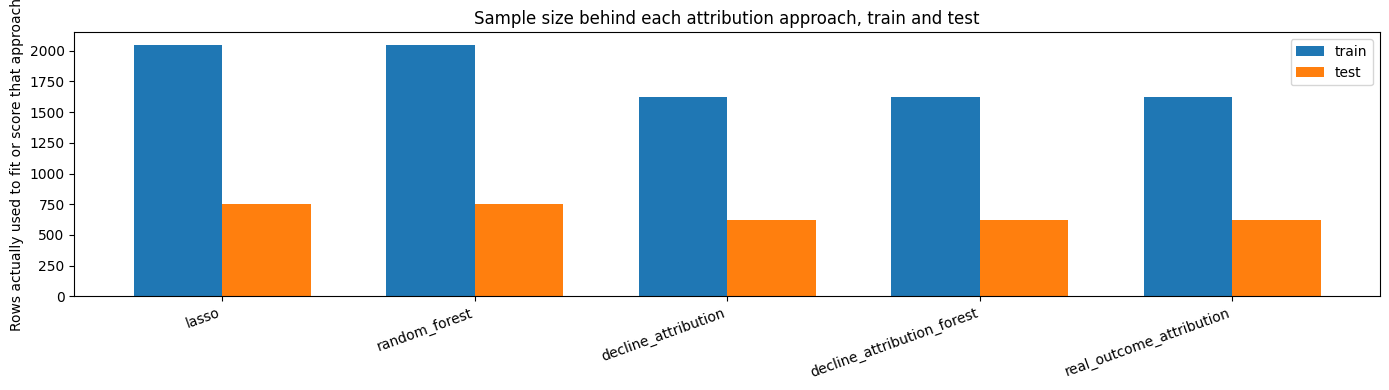

split,train,test,train_pct_of_lasso
approach,,,
lasso,2048,753,100.0
random_forest,2048,753,100.0
decline_attribution,1627,620,79.4
decline_attribution_forest,1627,620,79.4
real_outcome_attribution,1627,620,79.4


In [13]:
sample_size_rows = attribution_results[attribution_results['split'].isin(['train', 'test'])][['approach', 'split', 'n_rows']].copy()
sample_size_pivot = sample_size_rows.pivot(index='approach', columns='split', values='n_rows')
sample_size_pivot = sample_size_pivot.reindex([
    'lasso', 'random_forest', 'decline_attribution', 'decline_attribution_forest', 'real_outcome_attribution',
])[['train', 'test']]
sample_size_pivot['train_pct_of_lasso'] = (sample_size_pivot['train'] / sample_size_pivot.loc['lasso', 'train'] * 100).round(1)

fig, ax = plt.subplots(figsize=figsize)
x = np.arange(len(sample_size_pivot))
width = 0.35
ax.bar(x - width / 2, sample_size_pivot['train'], width, label='train')
ax.bar(x + width / 2, sample_size_pivot['test'], width, label='test')
ax.set_xticks(x)
ax.set_xticklabels(sample_size_pivot.index, rotation=20, ha='right')
ax.set_ylabel('Rows actually used to fit or score that approach')
ax.set_title('Sample size behind each attribution approach, train and test')
ax.legend()
plt.tight_layout()
plt.show()

sample_size_pivot

**Read train_pct_of_lasso as how much smaller a sample each approach's own point estimate and bootstrap interval actually rest on, lasso itself always at 100 percent since it is the least restrictive of the three notebooks.** decline_attribution, decline_attribution_forest, and real_outcome_attribution all run on the same 1627 train rows, 379 patients, a little over three quarters of lasso and random_forest's own 2048 rows, 414 patients, and the two pairs land on the exact same row count because both notebooks end up requiring the same next visit condition even though they ask for it for different reasons, decline needs a second reading to compute a slope from, real outcome needs a next visit to know whether DIAGNOSIS actually worsened. This is not a new number changing any conclusion 5.1 above already drew, the two notebooks reading RISK_SCORE still agree with each other more than either agrees with real_outcome_attribution, but it does mean that agreement, and that disagreement, are both being read off a smaller, though identically sized, patient sample than risk_factors/1_global.ipynb's own two rows enjoy, worth keeping in mind before treating every rho in 5.1 as resting on equally solid ground.

<a id="sec6"></a>

## 6. Cost Sensitivity

Every interval policy notebook above now also reruns its own policy at 1.5, at 2.8, and at 4.0 for MCI_OR_WORSE_COST_MULTIPLIER, the low end, the default, and the high end of the documented literature range described in each notebook's own section 3 and section 9, saving one row per multiplier to its own cost_sensitivity_*.csv file. This section reads all four files together, so the question section 3 already answered at the single default multiplier, which policy costs least, can be checked again across the whole plausible range at once, rather than trusting that the ranking found at 2.8 would still hold at 1.5 or at 4.0. forecast_adaptive's own file is read here too but kept out of the total_cost comparison below for the same reason section 3 above already explains, its total_cost is priced on a different scale at every multiplier, not only at 2.8, its own catch_rate trend is shown alongside the other three instead.

In [14]:
sensitivity_files = {
    'fixed_policy': 'cost_sensitivity_fixed_policy.csv',
    'snapshot_adaptive': 'cost_sensitivity_snapshot_adaptive.csv',
    'trajectory_adaptive': 'cost_sensitivity_trajectory_adaptive.csv',
    'forecast_adaptive': 'cost_sensitivity_forecast_adaptive.csv',
}

sensitivity_frames = []
for approach, filename in sensitivity_files.items():
    sensitivity_path = os.path.join(results_path, filename)
    if os.path.exists(sensitivity_path):
        sensitivity_frames.append(pd.read_csv(sensitivity_path))
    else:
        print(f'{filename} not found yet, run the {approach} notebook first.')

sensitivity_results = pd.concat(sensitivity_frames, ignore_index=True) if sensitivity_frames else pd.DataFrame()
sensitivity_results

,multiplier,approach,train_total_cost,test_total_cost,train_catch_rate,test_catch_rate
0,1.5,fixed_policy,44899.753307,16698.822882,87.624750,90.862944
1,2.8,fixed_policy,59987.590101,22479.361175,87.624750,90.862944
2,4.0,fixed_policy,73914.824064,27815.242676,87.624750,90.862944
3,1.5,snapshot_adaptive,39690.845347,14717.156236,84.231537,86.802030
4,2.8,snapshot_adaptive,49504.449871,18387.063297,84.431138,88.324873
5,4.0,snapshot_adaptive,57680.113039,21451.182782,93.612774,94.923858
6,1.5,trajectory_adaptive,40263.149763,14919.617083,84.630739,86.802030
7,2.8,trajectory_adaptive,50427.295572,18710.377293,84.830339,87.309645
8,4.0,trajectory_adaptive,58896.797779,21904.944243,93.812375,93.908629
9,1.5,forecast_adaptive,74241.107223,28001.631618,86.027944,90.862944


In [15]:
comparable_sensitivity = sensitivity_results[sensitivity_results['approach'] != 'forecast_adaptive']
for multiplier in sorted(comparable_sensitivity['multiplier'].unique()):
    at_multiplier = comparable_sensitivity[comparable_sensitivity['multiplier'] == multiplier].sort_values('test_total_cost')
    cheapest = at_multiplier.iloc[0]
    print(f"Multiplier {multiplier}, cheapest among the three directly comparable policies on test: {cheapest['approach']}, "
          f"total cost {cheapest['test_total_cost']:.1f}, "
          f"catch rate {cheapest['test_catch_rate']:.1f} percent")
    forecast_at_multiplier = sensitivity_results[
        (sensitivity_results['approach'] == 'forecast_adaptive') & (sensitivity_results['multiplier'] == multiplier)
    ]
    if len(forecast_at_multiplier) > 0:
        forecast_row = forecast_at_multiplier.iloc[0]
        print(f"  forecast_adaptive on its own, not directly comparable: "
              f"total cost {forecast_row['test_total_cost']:.1f}, "
              f"catch rate {forecast_row['test_catch_rate']:.1f} percent")

Multiplier 1.5, cheapest among the three directly comparable policies on test: snapshot_adaptive, total cost 14717.2, catch rate 86.8 percent
  forecast_adaptive on its own, not directly comparable: total cost 28001.6, catch rate 90.9 percent
Multiplier 2.8, cheapest among the three directly comparable policies on test: snapshot_adaptive, total cost 18387.1, catch rate 88.3 percent
  forecast_adaptive on its own, not directly comparable: total cost 38795.6, catch rate 91.4 percent
Multiplier 4.0, cheapest among the three directly comparable policies on test: snapshot_adaptive, total cost 21451.2, catch rate 94.9 percent
  forecast_adaptive on its own, not directly comparable: total cost 48662.3, catch rate 97.0 percent


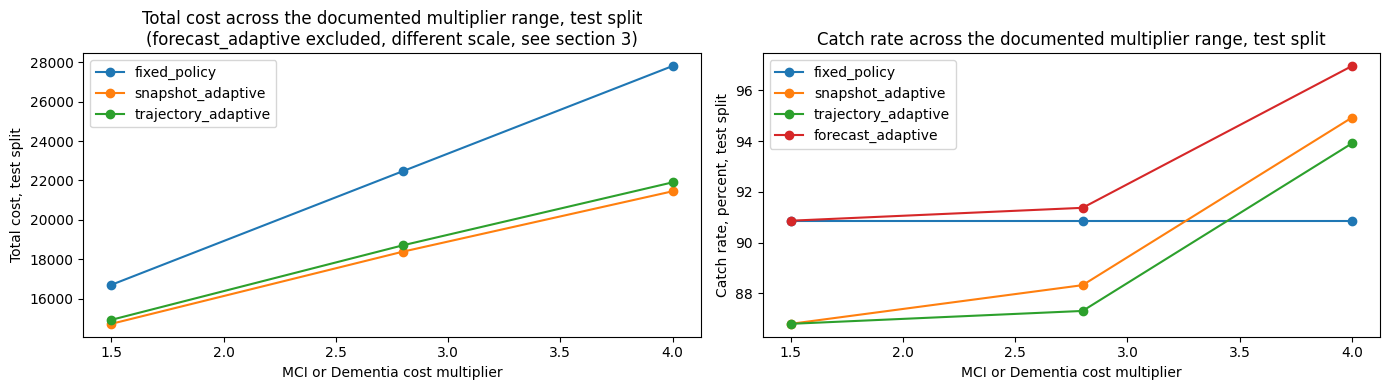

In [16]:
fig, axes = plt.subplots(1, 2, figsize=figsize)

for approach in ['fixed_policy', 'snapshot_adaptive', 'trajectory_adaptive']:
    approach_rows = sensitivity_results[sensitivity_results['approach'] == approach].sort_values('multiplier')
    if len(approach_rows) == 0:
        continue
    axes[0].plot(approach_rows['multiplier'], approach_rows['test_total_cost'], marker='o', label=approach)

for approach in ['fixed_policy', 'snapshot_adaptive', 'trajectory_adaptive', 'forecast_adaptive']:
    approach_rows = sensitivity_results[sensitivity_results['approach'] == approach].sort_values('multiplier')
    if len(approach_rows) == 0:
        continue
    axes[1].plot(approach_rows['multiplier'], approach_rows['test_catch_rate'], marker='o', label=approach)

axes[0].set_xlabel('MCI or Dementia cost multiplier')
axes[0].set_ylabel('Total cost, test split')
axes[0].set_title('Total cost across the documented multiplier range, test split\n(forecast_adaptive excluded, different scale, see section 3)')
axes[0].legend()

axes[1].set_xlabel('MCI or Dementia cost multiplier')
axes[1].set_ylabel('Catch rate, percent, test split')
axes[1].set_title('Catch rate across the documented multiplier range, test split')
axes[1].legend()

plt.tight_layout()
plt.show()

<a id="sec7"></a>

## 7. Overall

**Three separate answers, not one score.** The cheapest interval policy printed above, the fairness correction trade off charted above, and the attribution approaches printed above, answer three different questions about Point 3, which recommendation costs least, how much accuracy a given amount of fairness correction costs, and which biomarkers actually drive worsening, whether measured against RISK_SCORE or against a real recorded event. All three still share the same patient split, though RISK_SCORE itself no longer means one single thing project wide, fixed_policy, snapshot_adaptive, trajectory_adaptive, and forecast_adaptive now read the new hazard model, directly or through its own forecast columns, while the fairness correction variants and pipeline_health_index still read the older placeholder or a blend built on it, so rerunning the approach_*.ipynb notebooks and then this one remains the way to check whether extending the newer measure to those as well would change either answer. The interval policy question also now carries its own robustness check, section 6 above reruns the same three directly comparable policies across the documented cost multiplier range instead of only at the single default value, so whichever policy comes out cheapest above can be read together with how much of that ranking survives a different, still plausible cost assumption, forecast_adaptive's own sensitivity is checked too, on its own terms, not folded into that same ranking.

<a id="sec8"></a>

## 8. What Carries Forward

**The interval policy question now has a provisional answer, not a final one.** Point two now exists, `hazard_survival_model.ipynb`, section 2 above, and `fixed_policy`, `snapshot_adaptive`, `trajectory_adaptive`, and `forecast_adaptive` already read it directly, the last of those reading its forecast columns rather than its single point estimate, section 3 above explains why that makes its own total_cost a different quantity, not only a different number. `pipeline_health_index` does not yet read the new hazard model at all, it still blends the anomaly detection track's own Point 1 health index into the older placeholder risk score rather than into the new one, see `approach_pipeline_anomaly.ipynb` for exactly what was blended in and how. Rebuilding that same blend on top of the new hazard model instead of the placeholder is the natural next step this project has not yet taken, worth doing before trusting any ranking that includes `pipeline_health_index` against the other policies too far.

**The trajectory adaptive policy does not currently earn its own added complexity.** Against the real DIAGNOSIS worsening check above, snapshot_adaptive comes out cheaper and with a higher catch rate than trajectory_adaptive on both splits, so the more complex policy is not only unrewarded here, it is measurably behind on the two numbers that matter most. Section 4 of temporal_window/3_trajectory_adaptive.ipynb already shows part of why, more rows get pulled toward a longer interval than a shorter one, and RISK_SLOPE itself comes from only two visits, a first order estimate easily swung by a single early reading. Whether a smoother trajectory estimate would change this, or whether a two point slope is simply not trustworthy enough yet to act on, is now a real, answerable question this project has not yet asked, worth remembering as a next step rather than as a reason to drop the trajectory adaptive policy outright.

**The forecast adaptive policy prices real risk more honestly, but that pricing is not yet trustworthy enough to rank against the other three on total_cost alone.** temporal_window/4_forecast_adaptive.ipynb's own section 4 shows why, nearly every row with a real forecast collapses to the shortest, 3 month interval, because the fitted hazard model's own per step probabilities compound quickly across future steps, and hazard_survival_model.ipynb never checked whether those probabilities are calibrated, only whether they rank patients sensibly. A real calibration check on the hazard estimator itself, comparing predicted probability against observed frequency within bins, is the natural next step before this policy's own total_cost can be read as a real expected dollar figure rather than a demonstration that compounding an uncalibrated probability pushes a cost minimizing search toward the shortest interval almost everywhere it can reach.

**The dual lambda multiplier earns its own extra complexity, the fixed one currently does not.** The error bars in section 4 above turn the lesson's own claim, that a learned multiplier keeps more accuracy than a guessed one for a similar fairness level, into a checked result on this project's own placeholder RISK_SCORE, dual_lambda's test R2 interval tracks unconstrained closely while fixed_lambda's own test R2 interval falls entirely below zero. Whether alpha=5.0 was simply too strong a guess, or whether a fixed multiplier is inherently harder to tune well here, is a real follow up question, worth checking against a smaller fixed alpha before concluding the fixed multiplier approach itself is the problem.

**The attribution rankings above should be read together with their own confidence intervals, not the point estimates alone.** Lasso and decline_attribution's own test R2 intervals both cross zero in section 5 above, so on this run neither can currently be said with confidence to explain RISK_SCORE better than its own average would, even though their point estimates differ. This is most likely a placeholder RISK_SCORE problem rather than a biomarker problem, DIAGNOSIS and AMYLOID_STATUS alone, the two inputs placeholder_risk_score is built from, are a coarse target for eight continuous biomarkers to predict, exactly the gap real_outcome_attribution's own AUC in risk_factors/3_real_outcome.ipynb is meant to check directly against a real event instead.

**Fairness and explainability, on whichever policy this becomes, is intentionally not attempted here**, and the RUL track's own per row prediction is still an open input.

> **Status note, pending other tracks, resolve then delete:** the fairness and explainability design is meant to be settled jointly with the anomaly detection track rather than decided by Point 3 alone, since it touches that track's own output too, `approach_fairness_correction.ipynb`, `risk_factors/1_global.ipynb`, `risk_factors/2_decline.ipynb`, and `risk_factors/3_real_outcome.ipynb` stay as working, validated drafts of one way to do each half, not as the final word. Separately, the RUL track's own `rul_model_1.py` currently saves only a comparison across biomarker modalities, not a per row prediction the way Point 1's Method B saves per visit, so there is nothing yet in the same shape `approach_pipeline_anomaly.ipynb` could merge in, the natural next notebook once that export exists is the same pattern again, one more input, compared with and without.